# 10. 꽃 이미지 CNN 미니 프로젝트

이번 노트북의 목표는 폴더에 들어 있는 실제 꽃 이미지를 CNN 모델로 분류하는 것입니다.

이 장에서 중요한 흐름은 다음과 같습니다.

```text
이미지 폴더 확인
-> Keras 데이터셋으로 읽기
-> 이미지 크기 통일
-> 학습/검증 데이터 분리
-> CNN 모델 만들기
-> 학습
-> 예측
-> 저장
```

주의: 이 노트북은 CPU 환경에서도 돌아갈 수 있도록 작은 모델과 적은 epoch로 시작합니다.

## 1. 라이브러리 불러오기

이번 장부터는 이미지 데이터셋을 다루므로 `keras.utils.image_dataset_from_directory`를 사용합니다.

이 함수는 폴더 구조를 읽어서 이미지와 정답 라벨을 자동으로 만들어 줍니다.

In [1]:
# pathlib.Path는 파일 경로를 문자열보다 안전하고 읽기 쉽게 다루기 위한 도구입니다.
from pathlib import Path

# matplotlib.pyplot은 이미지와 그래프를 화면에 그릴 때 사용하는 대표 라이브러리입니다.
import matplotlib.pyplot as plt

# tensorflow는 Keras가 내부적으로 사용하는 딥러닝 계산 엔진입니다.
# 여기서는 데이터셋 성능 최적화 옵션을 쓰기 위해 불러옵니다.
import tensorflow as tf

# Sequential은 층을 위에서 아래로 차례대로 쌓는 가장 단순한 Keras 모델 방식입니다.
from keras.models import Sequential

# Input은 모델이 받을 데이터의 모양을 명시하는 층입니다.
# Conv2D는 이미지에서 작은 특징을 찾는 합성곱 층입니다.
# MaxPooling2D는 중요한 특징만 남기면서 이미지 크기를 줄이는 층입니다.
# Flatten은 2차원/3차원 특징 맵을 1줄 숫자 벡터로 펴는 층입니다.
# Dense는 앞 장에서 배운 완전연결층입니다.
# Dropout은 과적합을 줄이기 위해 학습 중 일부 연결을 임시로 끄는 층입니다.
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# RandomFlip, RandomRotation, RandomZoom은 이미지 데이터 증강에 사용하는 층입니다.
# Rescaling은 픽셀값을 0~255에서 0~1 범위로 바꾸는 층입니다.
from keras.layers import RandomFlip, RandomRotation, RandomZoom, Rescaling

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 경로 확인

이미지 데이터는 아래 폴더에 있습니다.

```text
C:\work\deepLearning\flower_dataset\flower_photos
```

이 폴더 안의 하위 폴더 이름이 곧 클래스 이름입니다.

In [2]:
# 꽃 이미지 데이터가 들어 있는 최상위 폴더입니다.
DATA_DIR = Path(r"C:\work\deepLearning\flower_dataset\flower_photos")

# exists()는 해당 경로가 실제로 존재하는지 True/False로 알려줍니다.
print("데이터 폴더 존재 여부:", DATA_DIR.exists())

# iterdir()는 폴더 안의 파일과 하위 폴더를 하나씩 꺼내 줍니다.
# is_dir()는 그 항목이 폴더인지 확인합니다.
class_folders = sorted([path for path in DATA_DIR.iterdir() if path.is_dir()])

print("클래스 폴더:")
for folder in class_folders:
    # folder.name은 전체 경로가 아니라 마지막 폴더 이름만 가져옵니다.
    print("-", folder.name)

데이터 폴더 존재 여부: True
클래스 폴더:
- daisy
- dandelion
- roses
- sunflowers
- tulips


In [3]:
# 각 클래스 폴더에 이미지가 몇 장 있는지 확인합니다.
# glob("*")은 폴더 안의 모든 파일/폴더를 찾습니다.
for folder in class_folders:
    image_count = len([path for path in folder.glob("*") if path.is_file()])
    print(f"{folder.name:12s}: {image_count}장")

daisy       : 633장
dandelion   : 898장
roses       : 641장
sunflowers  : 699장
tulips      : 799장


## 3. 이미지 몇 장 미리 보기

모델을 만들기 전에 데이터를 눈으로 확인하는 습관이 중요합니다.

이미지 분류에서 데이터 확인은 다음 질문에 답하기 위한 과정입니다.

```text
정말 꽃 사진인가?
폴더 이름과 이미지 내용이 맞는가?
이미지 품질이 너무 나쁘지는 않은가?
클래스별로 사진 분위기가 너무 다르지는 않은가?
```

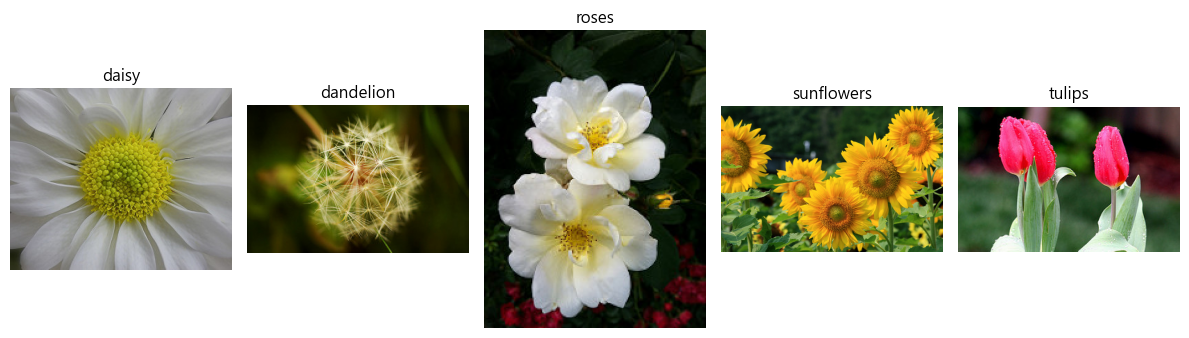

In [4]:
# 각 클래스에서 첫 번째 이미지 하나씩 가져와서 화면에 표시합니다.
plt.figure(figsize=(12, 4))

for index, folder in enumerate(class_folders):
    # list(folder.glob("*"))는 해당 폴더 안의 파일 목록을 리스트로 만듭니다.
    image_files = [path for path in folder.glob("*") if path.is_file()]
    
    # 파일이 하나도 없는 폴더가 있을 수 있으므로 안전하게 건너뜁니다.
    if len(image_files) == 0:
        continue
    
    # matplotlib의 imread는 이미지 파일을 숫자 배열로 읽습니다.
    sample_image = plt.imread(image_files[0])
    
    # subplot은 여러 그림을 한 화면에 나누어 그릴 때 사용합니다.
    plt.subplot(1, len(class_folders), index + 1)
    plt.imshow(sample_image)
    plt.title(folder.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. 이미지 데이터셋 만들기

`image_dataset_from_directory`는 폴더 구조를 읽어서 딥러닝 학습용 데이터셋을 만들어 줍니다.

이번 데이터에서는 하위 폴더 이름이 정답 이름입니다.

```text
daisy 폴더 안 이미지      -> 정답 daisy
dandelion 폴더 안 이미지  -> 정답 dandelion
roses 폴더 안 이미지      -> 정답 roses
sunflowers 폴더 안 이미지 -> 정답 sunflowers
tulips 폴더 안 이미지     -> 정답 tulips
```

`validation_split=0.2`는 전체 데이터 중 20%를 검증용으로 쓰겠다는 뜻입니다.

In [5]:
# 모든 이미지를 같은 크기로 맞춥니다.
# 크기가 커질수록 모델이 볼 수 있는 정보는 늘지만, 학습은 느려집니다.
IMG_SIZE = (160, 160)

# 한 번에 모델에 넣을 이미지 묶음 크기입니다.
# CPU 환경에서는 너무 크게 잡지 않는 편이 좋습니다.
BATCH_SIZE = 32

# 난수 고정값입니다.
# 학습/검증 분리가 매번 달라지지 않도록 seed를 지정합니다.
SEED = 42

# 학습용 데이터셋을 만듭니다.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,                  # 이미지를 담고 있는 최상위 폴더입니다.
    validation_split=0.2,      # 전체 데이터 중 20%를 검증용으로 분리합니다.
    subset="training",         # 그중 학습용 부분을 가져옵니다.
    seed=SEED,                 # 데이터를 섞고 나눌 때 사용할 고정 난수값입니다.
    image_size=IMG_SIZE,       # 모든 이미지를 이 크기로 바꿉니다.
    batch_size=BATCH_SIZE      # 이미지를 이 개수만큼 묶어서 가져옵니다.
)

# 검증용 데이터셋을 만듭니다.
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",       # 검증용 부분을 가져옵니다.
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [6]:
# class_names에는 Keras가 인식한 클래스 이름이 들어 있습니다.
# 폴더 이름을 알파벳 순서로 읽어서 클래스 번호를 붙입니다.
class_names = train_ds.class_names

print("클래스 이름:", class_names)
print("클래스 개수:", len(class_names))

클래스 이름: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
클래스 개수: 5


## 5. 데이터셋 한 묶음의 모양 확인

딥러닝에서는 shape 확인이 매우 중요합니다.

이번 장에서 이미지 한 묶음은 대략 다음 모양입니다.

```text
(배치 크기, 이미지 높이, 이미지 너비, 색상 채널 수)
```

예를 들어 `(32, 160, 160, 3)`은 160x160 컬러 이미지 32장을 뜻합니다.

In [7]:
# take(1)은 데이터셋에서 첫 번째 배치 하나만 꺼내겠다는 뜻입니다.
for images, labels in train_ds.take(1):
    print("이미지 배치 shape:", images.shape)
    print("정답 배치 shape:", labels.shape)
    print("첫 번째 이미지의 정답 번호:", labels[0].numpy())
    print("첫 번째 이미지의 정답 이름:", class_names[labels[0].numpy()])

이미지 배치 shape: (32, 160, 160, 3)
정답 배치 shape: (32,)
첫 번째 이미지의 정답 번호: 0
첫 번째 이미지의 정답 이름: daisy


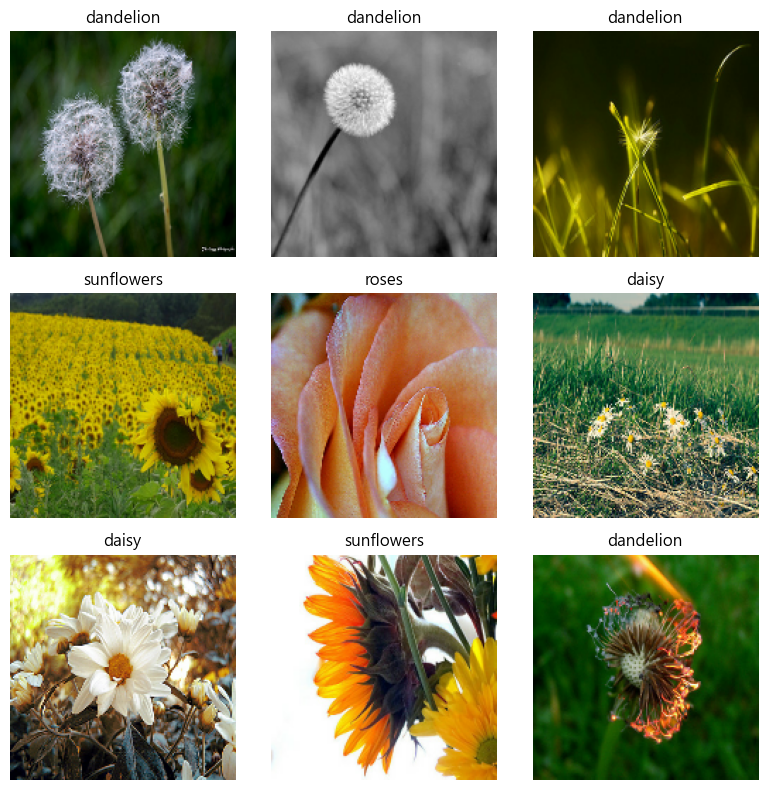

In [8]:
# 학습 데이터에서 이미지 9장을 미리 봅니다.
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        
        # images[i]는 i번째 이미지입니다.
        # image_dataset_from_directory가 이미 이미지를 숫자 배열로 바꿔 두었습니다.
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # labels[i]는 정답 번호입니다.
        # class_names를 이용해 사람이 읽을 수 있는 이름으로 바꿉니다.
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 6. 데이터셋 읽기 성능 조금 개선하기

이미지를 학습할 때는 데이터를 계속 읽어 와야 합니다.

`cache()`는 한 번 읽은 데이터를 메모리나 임시 저장소에 기억해 두는 역할을 합니다.

`prefetch()`는 모델이 현재 배치를 학습하는 동안 다음 배치를 미리 준비하는 역할을 합니다.

처음에는 이 코드를 완전히 이해하지 못해도 괜찮습니다. 지금은 “학습이 조금 더 매끄럽게 돌아가도록 도와주는 설정”으로 기억하면 됩니다.

In [9]:
# AUTOTUNE은 TensorFlow가 컴퓨터 상황에 맞춰 적절한 값을 자동으로 고르게 해줍니다.
AUTOTUNE = tf.data.AUTOTUNE

# cache()는 데이터를 반복해서 읽을 때 속도를 높이는 데 도움을 줍니다.
# prefetch()는 다음 배치를 미리 준비해서 학습 대기 시간을 줄입니다.
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 7. 데이터 증강 층 만들기

데이터 증강은 이미지를 살짝 변형해서 모델에게 보여주는 방법입니다.

모델은 매번 똑같은 사진만 보는 것이 아니라, 약간 뒤집히고, 약간 회전되고, 약간 확대된 사진도 보게 됩니다.

이렇게 하면 모델이 더 튼튼하게 배울 수 있습니다.

In [10]:
# 데이터 증강도 Keras 층처럼 만들 수 있습니다.
# 이 층들은 학습 중에만 이미지를 랜덤하게 바꿉니다.
data_augmentation = Sequential([
    # 좌우로 랜덤하게 뒤집습니다.
    RandomFlip("horizontal"),
    
    # 이미지를 아주 조금 랜덤하게 회전합니다.
    RandomRotation(0.1),
    
    # 이미지를 아주 조금 랜덤하게 확대하거나 축소합니다.
    RandomZoom(0.1),
], name="data_augmentation")

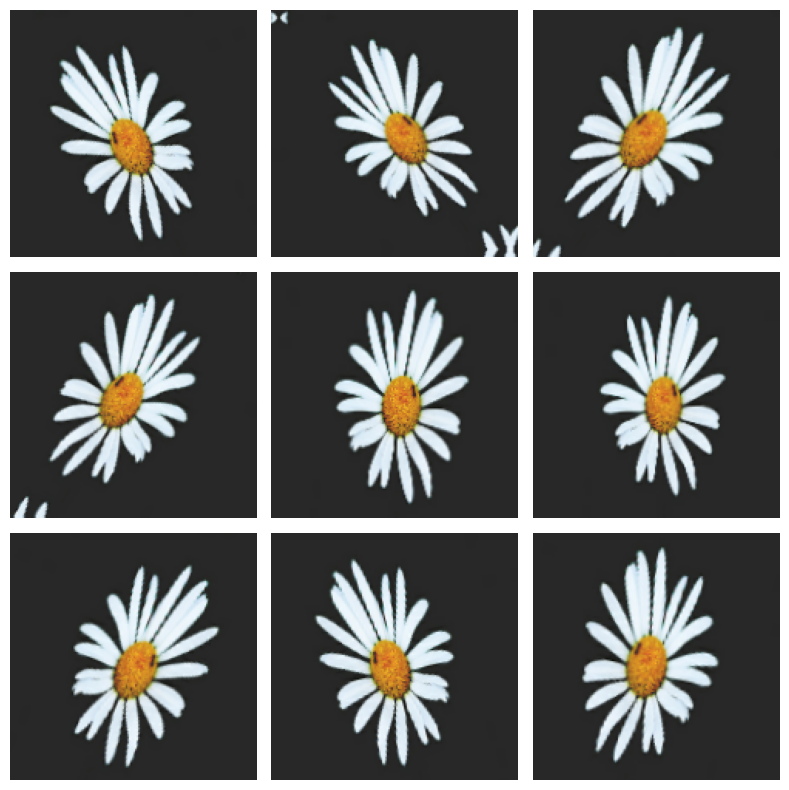

In [11]:
# 데이터 증강이 실제로 어떤 느낌인지 한 이미지에 적용해서 확인합니다.
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    first_image = images[0]
    
    # 단일 이미지를 배치 형태로 바꿉니다.
    # (160, 160, 3) -> (1, 160, 160, 3)
    first_image_batch = tf.expand_dims(first_image, axis=0)
    
    for i in range(9):
        # 배치 형태로 데이터 증강에 넣습니다.
        # training=True를 주면 데이터 증강 층이 실제로 랜덤 변형을 적용합니다.
        augmented_batch = data_augmentation(first_image_batch, training=True)
        
        # 화면에 보여줄 때는 다시 첫 번째 이미지만 꺼냅니다.
        augmented_image = augmented_batch[0]
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

## 8. CNN 모델 만들기

이번 모델은 작은 CNN입니다.

모델 흐름은 다음과 같습니다.

```text
입력
-> 데이터 증강
-> 픽셀값 0~1 변환
-> Conv2D / MaxPooling2D 반복
-> Flatten
-> Dense
-> Dropout
-> Dense 출력층
```

마지막 Dense의 뉴런 수는 클래스 개수와 같아야 합니다.

In [12]:
# 클래스 개수입니다.
# 이번 데이터에서는 daisy, dandelion, roses, sunflowers, tulips 총 5개입니다.
num_classes = len(class_names)

print(IMG_SIZE)
model = Sequential([
    # 입력 이미지의 모양을 알려줍니다.
    # IMG_SIZE는 (160, 160)이고, 컬러 이미지라서 채널 수 3을 붙입니다.
    Input(shape=IMG_SIZE + (3,)),
    
    # 학습 중 이미지에 랜덤 변형을 적용합니다.
    data_augmentation,
    
    # 픽셀값을 0~255에서 0~1 사이로 줄입니다.
    # 신경망은 보통 작은 숫자 범위에서 더 안정적으로 학습합니다.
    Rescaling(1.0 / 255),
    
    # 첫 번째 합성곱 블록입니다.
    # Conv2D는 이미지에서 작은 패턴을 찾습니다.
    Conv2D(16, kernel_size=3, activation="relu", padding="same"),
    
    # MaxPooling2D는 중요한 특징을 남기면서 가로/세로 크기를 줄입니다.
    MaxPooling2D(),
    
    # 두 번째 합성곱 블록입니다.
    Conv2D(32, kernel_size=3, activation="relu", padding="same"),
    MaxPooling2D(),
    
    # 세 번째 합성곱 블록입니다.
    Conv2D(64, kernel_size=3, activation="relu", padding="same"),
    MaxPooling2D(),
    
    # 3차원 특징 맵을 Dense 층에 넣기 위해 1차원으로 펼칩니다.
    Flatten(),
    
    # 이미지 특징을 조합해서 최종 판단에 가까운 정보를 만듭니다.
    Dense(128, activation="relu"),
    
    # 과적합을 줄이기 위해 학습 중 일부 뉴런 출력을 임시로 꺼 둡니다.
    Dropout(0.3),
    
    # 출력층입니다.
    # 클래스가 5개면 숫자 5개가 나오고, 각 숫자는 각 클래스에 대한 점수입니다.
    Dense(num_classes)
])

# summary()는 모델의 층 구조와 파라미터 수를 보여줍니다.
model.summary()

(160, 160)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,301,157 (12.59 MB)

 Trainable params: 3,301,157 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

## 9. 모델 컴파일

컴파일은 모델에게 학습 규칙을 알려주는 단계입니다.

```text
optimizer = 어떻게 고칠 것인가
loss = 얼마나 틀렸다고 볼 것인가
metrics = 학습 상황을 어떤 점수로 볼 것인가
```

이번 문제는 정답이 정수 번호인 다중 분류이므로 `SparseCategoricalCrossentropy`를 사용합니다.

In [13]:
# from_logits=True는 모델의 마지막 출력이 아직 softmax 확률이 아니라
# 클래스별 원점수(logit)라는 뜻입니다.
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    # adam은 딥러닝에서 자주 쓰는 최적화 방법입니다.
    optimizer="adam",
    
    # 다중 분류에서 정답 번호와 모델 출력의 차이를 계산합니다.
    loss=loss_fn,
    
    # accuracy는 전체 중 몇 개를 맞혔는지 보는 지표입니다.
    metrics=["accuracy"]
)

## 10. 모델 학습

`fit()`은 모델을 실제로 학습시키는 메서드입니다.

CPU 환경을 고려해서 기본 epoch를 작게 잡았습니다.

정확도를 크게 올리는 것보다, 먼저 전체 흐름을 이해하는 것이 이번 장의 목표입니다.

In [14]:
# EPOCHS는 전체 데이터를 몇 번 반복해서 학습할지 정하는 값입니다.
# 처음에는 3 정도로 작게 시작하고, 시간이 괜찮으면 나중에 늘립니다.
EPOCHS = 10

history = model.fit(
    train_ds,              # 학습용 데이터셋입니다.
    validation_data=val_ds, # 학습 중간중간 검증용 데이터셋으로 성능을 확인합니다.
    epochs=EPOCHS          # 전체 데이터 반복 횟수입니다.
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 227ms/step - accuracy: 0.4315 - loss: 1.3019 - val_accuracy: 0.5218 - val_loss: 1.1309
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.5770 - loss: 1.0673 - val_accuracy: 0.5926 - val_loss: 1.0407
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - accuracy: 0.6080 - loss: 0.9945 - val_accuracy: 0.6335 - val_loss: 0.9475
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.6396 - loss: 0.9154 - val_accuracy: 0.6676 - val_loss: 0.8945
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.6625 - loss: 0.8596 - val_accuracy: 0.6689 - val_loss: 0.9229
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.6826 - loss: 0.7955 - val_accuracy: 0.6689 - val_loss: 0.9859
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - accuracy: 0.7112 - loss: 0.7593 - val_accuracy: 0.7125 - val_loss: 0.8086
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.7221 - loss: 0.7314 - val_accu

## 11. 학습 곡선 그리기

학습 결과는 숫자 하나만 보면 부족합니다.

학습 정확도와 검증 정확도가 함께 좋아지는지 확인해야 합니다.

```text
accuracy     = 학습 데이터에서 맞힌 비율
val_accuracy = 검증 데이터에서 맞힌 비율
```

학습 정확도만 높고 검증 정확도가 낮다면 과적합을 의심할 수 있습니다.

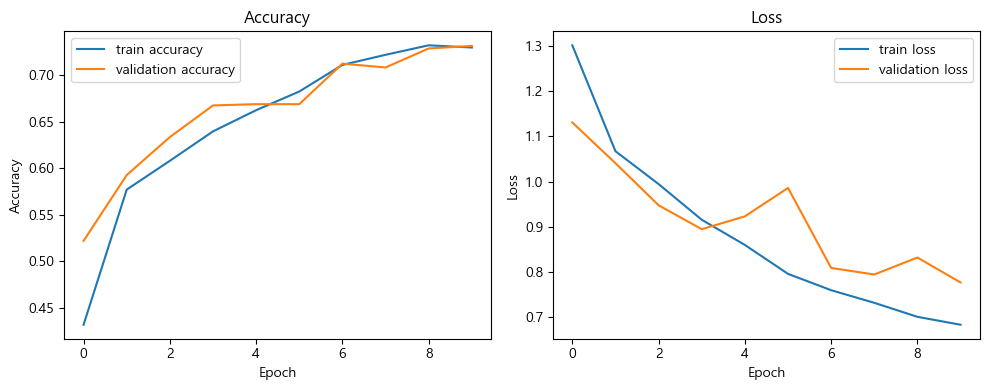

In [15]:
# history.history는 fit()이 기록한 학습 결과를 딕셔너리 형태로 가지고 있습니다.
history_dict = history.history

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="train accuracy")
plt.plot(history_dict["val_accuracy"], label="validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="train loss")
plt.plot(history_dict["val_loss"], label="validation loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 12. 예측 결과 확인

모델의 마지막 출력은 아직 확률이 아니라 클래스별 점수입니다.

그래서 `tf.nn.softmax()`를 사용해서 점수를 확률처럼 해석할 수 있는 값으로 바꿉니다.

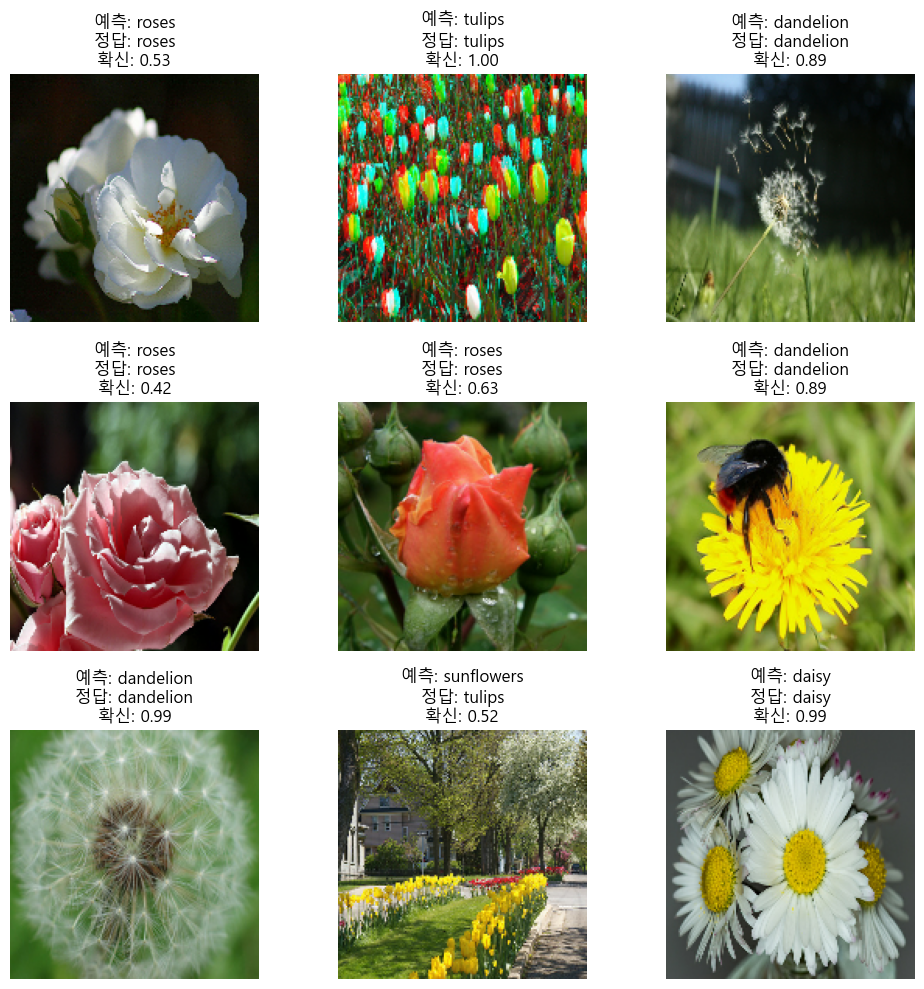

In [16]:
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):
    # predict()는 모델이 입력 이미지를 보고 예측한 값을 반환합니다.
    predictions = model.predict(images, verbose=0)
    
    # softmax는 클래스별 점수를 확률처럼 합이 1인 값으로 바꿉니다.
    probabilities = tf.nn.softmax(predictions, axis=1)
    
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # argmax는 가장 큰 값을 가진 위치를 찾습니다.
        # 즉, 가장 가능성이 높다고 본 클래스 번호를 고릅니다.
        predicted_index = int(tf.argmax(probabilities[i]).numpy())
        true_index = int(labels[i].numpy())
        
        predicted_name = class_names[predicted_index]
        true_name = class_names[true_index]
        
        # 가장 높은 예측 확률입니다.
        confidence = float(probabilities[i][predicted_index].numpy())
        
        title = f"예측: {predicted_name}\n정답: {true_name}\n확신: {confidence:.2f}"
        plt.title(title)
        plt.axis("off")

plt.tight_layout()
plt.show()

## 13. 모델 저장

학습한 모델은 저장해 두어야 나중에 다시 사용할 수 있습니다.

Keras 3에서는 `.keras` 형식 저장을 권장합니다.

In [17]:
# 저장할 폴더를 정합니다.
MODEL_DIR = Path(r"C:\work\deepLearning\model")

# mkdir()은 폴더를 만듭니다.
# parents=True는 중간 폴더가 없으면 함께 만들라는 뜻입니다.
# exist_ok=True는 이미 폴더가 있어도 오류를 내지 말라는 뜻입니다.
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Keras 3 권장 저장 형식입니다.
model_path = MODEL_DIR / "flower_cnn_mini_project.keras"

# save()는 모델 구조와 학습된 가중치를 파일로 저장합니다.
model.save(model_path)

print("저장 완료:", model_path)

저장 완료: C:\work\deepLearning\model\flower_cnn_mini_project.keras


## 14. 이번 장 정리

이번 장에서 배운 핵심은 다음과 같습니다.

```text
1. 폴더 이름을 정답 이름으로 사용할 수 있다.
2. image_dataset_from_directory로 이미지 파일을 Keras 데이터셋으로 바꿀 수 있다.
3. CNN은 실제 사진 분류에도 사용할 수 있다.
4. 데이터 증강은 모델이 사진을 더 유연하게 보도록 돕는다.
5. 모델 저장은 프로젝트 결과물을 남기기 위한 필수 단계다.
```

다음 장에서는 모델이 어떤 이미지를 틀렸는지 더 자세히 확인합니다.

## 과제

1. `IMG_SIZE = (128, 128)`로 줄이면 학습 속도와 정확도에 어떤 변화가 생길지 예상해보세요.
2. `EPOCHS = 5`로 늘리면 어떤 장점과 단점이 있을지 적어보세요.
3. `Dropout(0.3)`을 `Dropout(0.5)`로 바꾸면 과적합에 어떤 영향을 줄지 설명해보세요.
4. 검증 이미지 중 틀린 예측을 왜 확인해야 하는지 자기 말로 적어보세요.